## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
#bushel kelimesi geçen satırları seçiyoruz
#fiyatlar farklı paket turlerine gore değişiyor
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

#sadece gerekli sütunları seçiyoruz
columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]#tüm satırlar, sadece istenen sütunlar

#ortalama fiyatı hesaplıyoruz daha stabil regresyon için daha uygun
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

#String tarihleri → datetime objesine çevirir ordan da ay değerlerini çeker
month = pd.DatetimeIndex(pumpkins['Date']).month
#datetime tarih formatatlarını otomatik tanır pandasın datetime tipine donusturur
#String tarihleri → datetime objesine çevirir ordan da ay değerlerini çeker
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

#yeni dataframe olusturuyoruz
new_pumpkins = pd.DataFrame(
    {'Month': month,
     'DayOfYear' : day_of_year, 
     'Variety': pumpkins['Variety'], 
     'City': pumpkins['City Name'], 
     'Package': pumpkins['Package'], 
     'Low Price': pumpkins['Low Price'],
     'High Price': pumpkins['High Price'], 
     'Price': price})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()


/var/folders/yp/pkv5qv7x6v11fn_9wtqqf68w0000gn/T/ipykernel_51155/2637987050.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

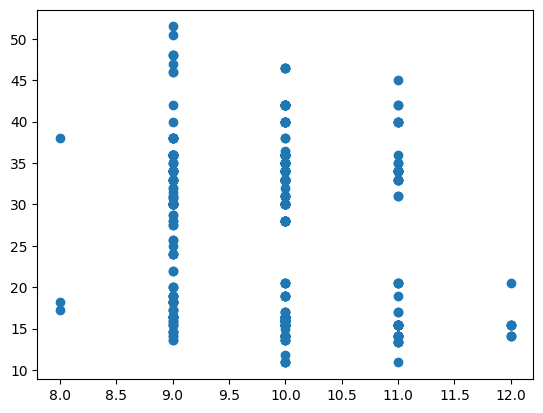

In [ ]:
import matplotlib.pyplot as plt
#dağılım grafiği bagımsız degişken ile hedef arasındaki ilişki
plt.scatter('Month','Price',data=new_pumpkins)

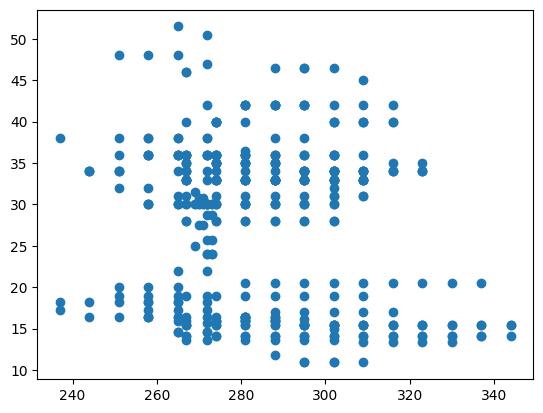

In [ ]:

plt.scatter('DayOfYear','Price',data=new_pumpkins)

In [40]:
#ay ve fiyat arasındaki korelasyon
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))

#bir gun ve fiyat arasındaki korelasyon
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.1487829355407754
-0.16673322492745402


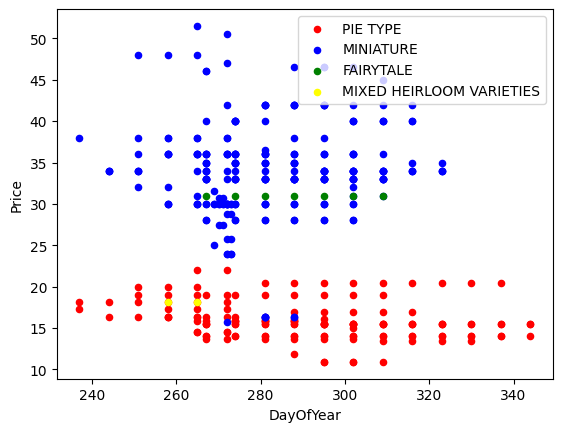

In [ ]:
colors = ['red', 'blue', 'green', 'yellow']
#Farklı kabak türlerinin (Variety), yıl içindeki zamana göre 
#fiyat davranışlarını aynı grafikte karşılaştırmak.

ax = None
for i,var in enumerate(new_pumpkins['Variety'].unique()):#benzersiz kabak turlerini dolanıyor
    df = new_pumpkins[new_pumpkins['Variety'] == var]#new_pumpkin[kabak turu == var]
    ax = df.plot.scatter('DayOfYear', 'Price', c=colors[i], label=var, ax=ax)
    #zamana göre fiyatı çizdiriyor

<Axes: xlabel='Variety'>

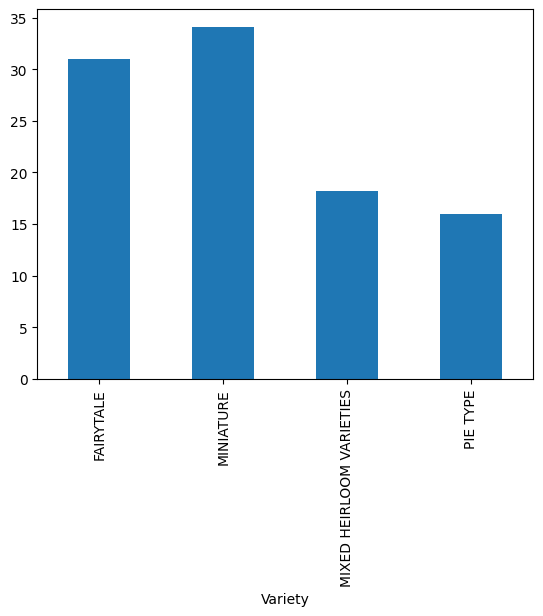

In [62]:
new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar')
#degerleri variety e gore grupluyor
#her variety için ort fiyat hesaplıyor
#mean genel fiyat seviyesini gosteriyor bu bir aggregation adımı
#.plot(kind='bar') çubuk grafik çizdiriyor

<Axes: xlabel='DayOfYear', ylabel='Price'>

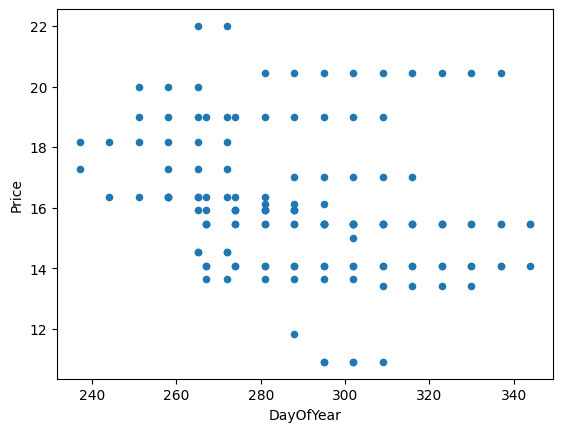

In [ ]:
pie_pumpkins = new_pumpkins[new_pumpkins['Variety'] == 'PIE TYPE']#new_pumpkinsin filtrelenmiş bir kopyası
pie_pumpkins.plot.scatter('DayOfYear','Price')

In [ ]:
print(pie_pumpkins['Month'].corr(pie_pumpkins['Price']))#koreasyon hesaplama

print(pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))


-0.23841413206125708
-0.26691922821973185


In [ ]:
pie_pumpkins.dropna(inplace=True)#eksik deger silme
#inplace=True orijinal dataframe i degiştirir
pie_pumpkins.info()#df hakkınd ozet bilgi

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 70 to 1630
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       144 non-null    int32  
 1   DayOfYear   144 non-null    int64  
 2   Variety     144 non-null    object 
 3   City        144 non-null    object 
 4   Package     144 non-null    object 
 5   Low Price   144 non-null    float64
 6   High Price  144 non-null    float64
 7   Price       144 non-null    float64
dtypes: float64(3), int32(1), int64(1), object(3)
memory usage: 9.6+ KB


/var/folders/yp/pkv5qv7x6v11fn_9wtqqf68w0000gn/T/ipykernel_51155/3144308612.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pie_pumpkins.dropna(inplace=True)


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
#arrayleri aldık [[]] dataframe  []series oluyor
#Scikit-learn modelleri pandas değil, NumPy array ile çalışır
X = pie_pumpkins[['DayOfYear']].to_numpy().reshape(-1,1)
y = pie_pumpkins['Price']#hedef değişkeni seciyor

X.shape

(144, 1)


(144, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#random state = 0 her seferinde aynı bölmeyi yapar rastgele ama tekrarlanabilir

In [49]:
lin_reg = LinearRegression()

#modeli eğit
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
#test the model
pred = lin_reg.predict(X_test)
pred

array([16.21096253, 16.73652536, 16.08833121, 15.35254325, 15.96569988,
       16.73652536, 16.21096253, 16.36863138, 16.61389403, 15.84306855,
       15.84306855, 15.72043723, 16.21096253, 15.5978059 , 16.45622519,
       15.72043723, 15.5978059 , 16.08833121, 15.72043723, 16.36863138,
       16.85915669, 16.21096253, 15.22991192, 16.21096253, 15.84306855,
       16.45622519, 16.08833121, 15.84306855, 15.5978059 ])

In [ ]:
#mean square error hesapla
mse = np.sqrt(mean_squared_error(y_test, pred))

#hatayı tahminlerin ortalamasına göre yüzdelik olarak göster
print(f"mean error : {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)")


mean error : 2.77 (17.2%)


In [ ]:
#coeffient of determination aynı ınputlarla aynı sonucları verip vermedigini kontrol eder
score = lin_reg.score(X_train, y_train)
print("model determination:",score)

model determination: 0.04460606335028361


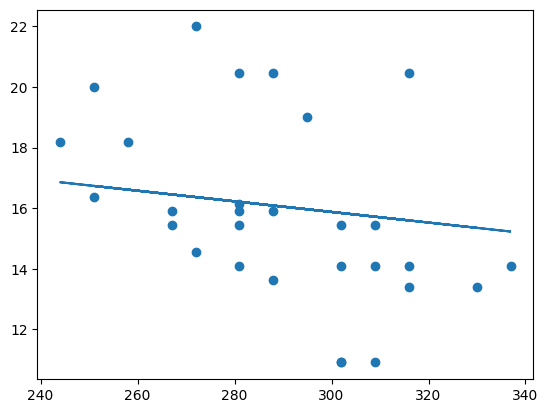

In [53]:
#test datası ile scatter plot yap
plt.scatter(X_test, y_test)

plt.plot(X_test, pred)

In [54]:
print(f"y = {lin_reg.coef_[0]}x + {lin_reg.intercept_}")

y = -0.017518760953104996x + 21.133734359909326


In [55]:
lin_reg.predict([[256]])

array([16.64893156])

mean error : 2.73 (17.0%)


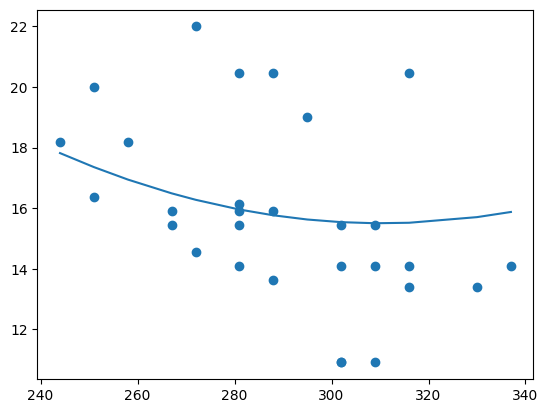

In [56]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

#polinomal regresyon pipelineı olusturma
pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

#modeli inşa etmek için kullan
pipeline.fit(X_train, y_train)

#modeli test et
pred = pipeline.predict(X_test)

#mean square error hesapla
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"mean error : {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)")

#plot the result
plt.scatter(X_test, y_test)
plt.plot(sorted(X_test),pipeline.predict(sorted(X_test)))


In [57]:
#model skoru
score = pipeline.score(X_train, y_train)
print("model determination:",score)

model determination: 0.07639977655280161


In [58]:
#kategorik değişken yapma 
X = pd.get_dummies(new_pumpkins['Variety'])\
                .join(new_pumpkins['Month'])\
                .join(pd.get_dummies(new_pumpkins['City']))\
                .join(pd.get_dummies(new_pumpkins['Package']))

y = new_pumpkins['Price']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#create a linear regression object
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

#test the model
pred = pipeline.predict(X_test)

#calculate mean square error
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"mean error : {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)")

#calculate the coefficients of determination
score = pipeline.score(X_train, y_train)
print("model determination:",score)




mean error : 2.23 (8.28%)
model determination: 0.9653029999448537


In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#polinomal regresyon pipelineı olusturma
pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

#modeli inşa etmek için kullan
pipeline.fit(X_train, y_train)

#modeli test et
pred = pipeline.predict(X_test)

#mean square error hesapla
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"mean error : {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)")


#model skoru
score = pipeline.score(X_train, y_train)
print("model determination:",score)


mean error : 2.73 (17.0%)
model determination: 0.07639977655280161
